# SIH26139 — Hybrid Quantum–Classical ML for **Early 10-Year CHD Risk Prediction**

**Goal:** predict whether a patient will develop coronary heart disease (CHD) within 10 years from baseline clinical measurements, then compare:

1. **Classical ML (CML)** — Logistic Regression, RBF-SVM, Random Forest, HistGradientBoosting
2. **Quantum ML (QML)** — quantum-kernel SVM
3. **Hybrid CML + QML** — out-of-fold stacking of a classical model and quantum-kernel model

This is a **risk-prediction research prototype**, not a medical diagnostic device.

### Why this demonstrates “early” prediction
The target is a *future* event (`TenYearCHD`): baseline measurements are used to estimate CHD occurrence during subsequent follow-up. This is stronger than classifying an already diagnosed disease.

### Why this is genuinely hybrid
Classical preprocessing/feature selection reduces the biomedical feature space to a small qubit-compatible representation. A classical branch and a quantum-kernel branch then make independent predictions; an out-of-fold meta-learner fuses both branches without training-set prediction leakage.

In [2]:
# Kaggle setup — run once. Internet must be enabled if these packages are not already cached.
!pip -q install "pennylane>=0.36,<0.44" imbalanced-learn

In [3]:
import os, glob, time, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, balanced_accuracy_score)
import pennylane as qml

SEED = 42
np.random.seed(SEED); random.seed(SEED)
print("PennyLane:", qml.__version__)

PennyLane: 0.43.3


## 1. Load the Framingham dataset

Add a Kaggle dataset containing the common Framingham CSV to the notebook. The loader searches `/kaggle/input` automatically and looks for a target column such as `TenYearCHD`.

In [4]:
TARGET_CANDIDATES = ["TenYearCHD", "tenyearchd", "TenYearCHD_risk"]

csvs = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print("CSV files found:", len(csvs))

DATA_PATH = None
for p in csvs:
    try:
        cols = pd.read_csv(p, nrows=2).columns.tolist()
        if any(t in cols for t in TARGET_CANDIDATES):
            DATA_PATH = p; break
    except Exception:
        pass

if DATA_PATH is None:
    raise FileNotFoundError(
        "No Framingham CSV with TenYearCHD found. In Kaggle choose Add Input, add a Framingham Heart Study dataset, then rerun."
    )

print("Using:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

CSV files found: 1
Using: /kaggle/input/datasets/captainozlem/framingham-chd-preprocessed-data/CHD_preprocessed.csv
Shape: (4133, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,1,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
# Standardize column naming variants seen in public Framingham copies
rename_map = {
    "male":"sex_male", "Male":"sex_male",
    "education":"education", "currentSmoker":"currentSmoker", "cigsPerDay":"cigsPerDay",
    "BPMeds":"BPMeds", "prevalentStroke":"prevalentStroke", "prevalentHyp":"prevalentHyp",
    "diabetes":"diabetes", "totChol":"totChol", "sysBP":"sysBP", "diaBP":"diaBP",
    "BMI":"BMI", "heartRate":"heartRate", "glucose":"glucose"
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})
TARGET = next((t for t in TARGET_CANDIDATES if t in df.columns), None)
assert TARGET is not None

# Remove obvious IDs if present
id_like = [c for c in df.columns if c.lower() in {"id","patientid","patient_id"}]
df = df.drop(columns=id_like, errors="ignore")

print(df.dtypes)
print("\nTarget distribution:")
print(df[TARGET].value_counts(dropna=False))
print(df[TARGET].value_counts(normalize=True).rename("proportion"))

sex_male             int64
age                  int64
education            int64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Target distribution:
TenYearCHD
0    3505
1     628
Name: count, dtype: int64
TenYearCHD
0    0.848052
1    0.151948
Name: proportion, dtype: float64


## 2. Data audit
We inspect missingness and class imbalance before modeling. For medical risk prediction, **AUROC, AUPRC, sensitivity and specificity** are more informative than accuracy alone when events are relatively uncommon.

,dtype,missing_n,missing_%,unique
sex_male,int64,0,0.0,2
age,int64,0,0.0,39
education,int64,0,0.0,2
currentSmoker,int64,0,0.0,2
cigsPerDay,float64,0,0.0,33
BPMeds,float64,0,0.0,2
prevalentStroke,int64,0,0.0,2
prevalentHyp,int64,0,0.0,2
diabetes,int64,0,0.0,2
totChol,float64,0,0.0,247


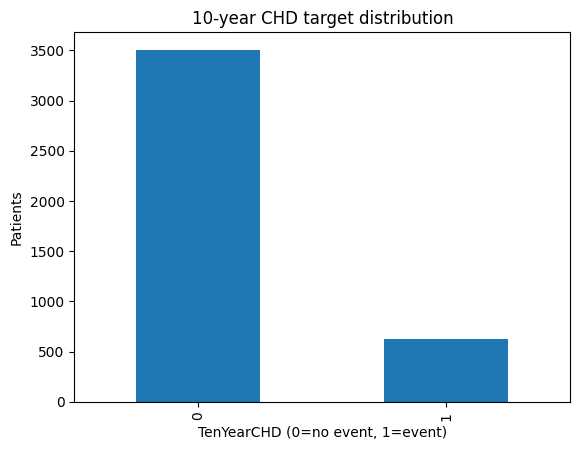

In [6]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_%": (100*df.isna().mean()).round(2),
    "unique": df.nunique()
}).sort_values("missing_%", ascending=False)
display(audit)

ax = df[TARGET].value_counts().sort_index().plot(kind="bar", title="10-year CHD target distribution")
ax.set_xlabel("TenYearCHD (0=no event, 1=event)"); ax.set_ylabel("Patients")
plt.show()

## 3. Leakage-safe train/test split and preprocessing

The test set is isolated **before** imputation, scaling, feature selection, or model fitting. This is essential for credible benchmarking.

In [7]:
X = df.drop(columns=[TARGET]).copy()
y = pd.to_numeric(df[TARGET], errors="coerce")
valid = y.notna()
X, y = X.loc[valid], y.loc[valid].astype(int)

# Keep numeric/binary clinical columns; common Framingham copies are numeric.
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train event rate:", y_train.mean().round(3), " Test event rate:", y_test.mean().round(3))

Train: (3306, 15)  Test: (827, 15)
Train event rate: 0.152  Test event rate: 0.152


In [8]:
# One reusable preprocessing pipeline: median imputation + standardization
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)
feature_names = X_train.columns.to_numpy()

# Feature selection is learned ONLY from training data.
mi = mutual_info_classif(Xtr, y_train, random_state=SEED)
feature_rank = pd.DataFrame({"feature": feature_names, "mutual_information": mi}).sort_values(
    "mutual_information", ascending=False
)
display(feature_rank)

,feature,mutual_information
1,age,0.027530
10,sysBP,0.024378
7,prevalentHyp,0.018443
11,diaBP,0.014819
0,sex_male,0.008072
8,diabetes,0.006870
9,totChol,0.005265
12,BMI,0.004630
5,BPMeds,0.003593
3,currentSmoker,0.003052


## 4. Classical baselines
We intentionally include several strong and interpretable baselines. Class weighting is used where supported because the positive CHD class is usually the minority.

In [9]:
classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
    "RBF-SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced", min_samples_leaf=3,
                                             random_state=SEED, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05,
                                                            max_leaf_nodes=15, random_state=SEED)
}

def metrics_row(name, y_true, prob, threshold=0.5, seconds=np.nan):
    pred = (np.asarray(prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    specificity = tn/(tn+fp) if (tn+fp) else np.nan
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true,pred),
        "Balanced Acc": balanced_accuracy_score(y_true,pred),
        "Precision": precision_score(y_true,pred,zero_division=0),
        "Sensitivity": recall_score(y_true,pred,zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true,pred,zero_division=0),
        "AUROC": roc_auc_score(y_true,prob),
        "AUPRC": average_precision_score(y_true,prob),
        "Time_s": seconds
    }

results=[]; test_probs={}
for name, model in classical_models.items():
    t=time.time(); model.fit(Xtr,y_train); prob=model.predict_proba(Xte)[:,1]; dt=time.time()-t
    results.append(metrics_row(name,y_test,prob,seconds=dt)); test_probs[name]=prob

pd.DataFrame(results).sort_values("AUROC",ascending=False).round(4)

,Model,Accuracy,Balanced Acc,Precision,Sensitivity,Specificity,F1,AUROC,AUPRC,Time_s
0,Logistic Regression,0.6989,0.6694,0.2811,0.6270,0.7118,0.3882,0.7345,0.3603,0.0210
2,Random Forest,0.8380,0.5594,0.4167,0.1587,0.9601,0.2299,0.7016,0.3362,1.3182
1,RBF-SVM,0.8476,0.5000,0.0000,0.0000,1.0000,0.0000,0.6886,0.2581,2.2919
3,HistGradientBoosting,0.8452,0.5441,0.4667,0.1111,0.9772,0.1795,0.6775,0.2903,0.3815


## 5. Select a compact quantum feature set

Near-term devices have limited qubits. We therefore select the strongest training-only features and encode them into **4 qubits** by default. Change `N_QUBITS` to explore scaling.

In [10]:
N_QUBITS = 4
selected = feature_rank.head(N_QUBITS)["feature"].tolist()
idx = [list(feature_names).index(c) for c in selected]
Xq_train = Xtr[:, idx]
Xq_test = Xte[:, idx]

# Bound standardized values to a stable angular encoding range.
Xq_train = np.clip(Xq_train, -3, 3) * (np.pi/3)
Xq_test  = np.clip(Xq_test,  -3, 3) * (np.pi/3)
print("Quantum features:", selected)

Quantum features: ['age', 'sysBP', 'prevalentHyp', 'diaBP']


## 6. Quantum kernel

We encode each patient as a quantum state $|\phi(x)\rangle$ and use state overlap as a kernel:

$$K_Q(x_i,x_j)=|\langle\phi(x_i)|\phi(x_j)\rangle|^2.$$

The circuit uses angle encoding plus ring entanglement. The kernel is evaluated on PennyLane's state-vector simulator, making this reproducible on Kaggle. The same circuit design can later be adapted to shot/noise/hardware backends.

In [11]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev)
def feature_state(x):
    for w in range(N_QUBITS):
        qml.Hadamard(wires=w)
        qml.RY(x[w], wires=w)
        qml.RZ(0.5*x[w], wires=w)
    for w in range(N_QUBITS):
        qml.CZ(wires=[w, (w+1) % N_QUBITS])
    for w in range(N_QUBITS):
        qml.RY(x[w]**2/np.pi, wires=w)
    return qml.state()

def state_matrix(Xarr):
    return np.asarray([feature_state(x) for x in Xarr])

def quantum_kernel_from_states(A, B):
    # |<a|b>|^2, vectorized
    return np.abs(A @ B.conj().T)**2

# Circuit preview
print(qml.draw(feature_state)(Xq_train[0]))

0: ──H──RY(-0.20)──RZ(-0.10)─╭●───────╭Z──RY(0.01)─┤  State
1: ──H──RY(-0.29)──RZ(-0.15)─╰Z─╭●────│───RY(0.03)─┤  State
2: ──H──RY(-0.72)──RZ(-0.36)────╰Z─╭●─│───RY(0.16)─┤  State
3: ──H──RY(0.73)───RZ(0.37)────────╰Z─╰●──RY(0.17)─┤  State


### Computational budget
Exact quantum kernels scale quadratically in the number of training samples. To keep a Kaggle/near-term demo practical, the QML branch uses a **stratified training subset**. Increase `Q_TRAIN_MAX` if compute permits. Classical baselines continue to use the full training set.

In [12]:
Q_TRAIN_MAX = min(500, len(Xq_train))
if len(Xq_train) > Q_TRAIN_MAX:
    q_idx, _ = train_test_split(np.arange(len(Xq_train)), train_size=Q_TRAIN_MAX,
                                stratify=y_train, random_state=SEED)
else:
    q_idx = np.arange(len(Xq_train))

Xq_sub = Xq_train[q_idx]
yq_sub = y_train.iloc[q_idx].reset_index(drop=True)

start=time.time()
S_train = state_matrix(Xq_sub)
S_test = state_matrix(Xq_test)
K_train = quantum_kernel_from_states(S_train,S_train)
K_test = quantum_kernel_from_states(S_test,S_train)

qsvc = SVC(kernel="precomputed", probability=True, class_weight="balanced", random_state=SEED)
qsvc.fit(K_train,yq_sub)
q_prob = qsvc.predict_proba(K_test)[:,1]
q_time=time.time()-start

test_probs["Quantum Kernel SVM"] = q_prob
results.append(metrics_row("Quantum Kernel SVM",y_test,q_prob,seconds=q_time))
pd.DataFrame(results).sort_values("AUROC",ascending=False).round(4)

,Model,Accuracy,Balanced Acc,Precision,Sensitivity,Specificity,F1,AUROC,AUPRC,Time_s
0,Logistic Regression,0.6989,0.6694,0.2811,0.6270,0.7118,0.3882,0.7345,0.3603,0.0210
2,Random Forest,0.8380,0.5594,0.4167,0.1587,0.9601,0.2299,0.7016,0.3362,1.3182
1,RBF-SVM,0.8476,0.5000,0.0000,0.0000,1.0000,0.0000,0.6886,0.2581,2.2919
3,HistGradientBoosting,0.8452,0.5441,0.4667,0.1111,0.9772,0.1795,0.6775,0.2903,0.3815
4,Quantum Kernel SVM,0.8452,0.5018,0.2500,0.0079,0.9957,0.0154,0.6581,0.2535,3.7862


## 7. Genuine hybrid CML + QML via out-of-fold stacking

The hybrid branch fuses:

- **Classical:** RBF-SVM probability from the full selected clinical representation
- **Quantum:** quantum-kernel SVM probability from the compact qubit representation
- **Fusion:** logistic meta-learner

To prevent stacking leakage, the meta-learner sees only **out-of-fold (OOF)** predictions for training patients.

In [13]:
# For tractable, fair OOF quantum stacking, work on the same stratified quantum subset.
Xc_h = Xtr[q_idx]
Xq_h = Xq_train[q_idx]
y_h = y_train.iloc[q_idx].reset_index(drop=True)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_c = np.zeros(len(y_h)); oof_q = np.zeros(len(y_h))

start=time.time()
for fold,(tr,va) in enumerate(skf.split(Xc_h,y_h),1):
    # Classical branch
    c = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED+fold)
    c.fit(Xc_h[tr],y_h.iloc[tr])
    oof_c[va] = c.predict_proba(Xc_h[va])[:,1]

    # Quantum branch — states computed only for this fold's samples
    Str = state_matrix(Xq_h[tr]); Sva = state_matrix(Xq_h[va])
    Ktr = quantum_kernel_from_states(Str,Str)
    Kva = quantum_kernel_from_states(Sva,Str)
    q = SVC(kernel="precomputed", probability=True, class_weight="balanced", random_state=SEED+fold)
    q.fit(Ktr,y_h.iloc[tr])
    oof_q[va] = q.predict_proba(Kva)[:,1]
    print(f"Fold {fold}/{N_SPLITS} done")

meta = LogisticRegression(class_weight="balanced",random_state=SEED)
meta.fit(np.c_[oof_c,oof_q],y_h)

# Refit base branches on all hybrid-training patients
c_final = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)
c_final.fit(Xc_h,y_h)
c_test = c_final.predict_proba(Xte)[:,1]

Sh = state_matrix(Xq_h); Ste = state_matrix(Xq_test)
Kh = quantum_kernel_from_states(Sh,Sh); Kte = quantum_kernel_from_states(Ste,Sh)
q_final = SVC(kernel="precomputed", probability=True, class_weight="balanced", random_state=SEED)
q_final.fit(Kh,y_h)
q_test = q_final.predict_proba(Kte)[:,1]

hybrid_prob = meta.predict_proba(np.c_[c_test,q_test])[:,1]
hybrid_time=time.time()-start

test_probs["Hybrid CML + QML"] = hybrid_prob
results.append(metrics_row("Hybrid CML + QML",y_test,hybrid_prob,seconds=hybrid_time))
summary = pd.DataFrame(results).drop_duplicates("Model",keep="last").sort_values("AUROC",ascending=False)
display(summary.round(4))
print("Meta weights [classical, quantum]:", meta.coef_.round(3).tolist())

Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done


,Model,Accuracy,Balanced Acc,Precision,Sensitivity,Specificity,F1,AUROC,AUPRC,Time_s
0,Logistic Regression,0.6989,0.6694,0.2811,0.6270,0.7118,0.3882,0.7345,0.3603,0.0210
5,Hybrid CML + QML,0.7207,0.6204,0.2667,0.4762,0.7646,0.3419,0.7062,0.2727,11.4532
2,Random Forest,0.8380,0.5594,0.4167,0.1587,0.9601,0.2299,0.7016,0.3362,1.3182
1,RBF-SVM,0.8476,0.5000,0.0000,0.0000,1.0000,0.0000,0.6886,0.2581,2.2919
3,HistGradientBoosting,0.8452,0.5441,0.4667,0.1111,0.9772,0.1795,0.6775,0.2903,0.3815
4,Quantum Kernel SVM,0.8452,0.5018,0.2500,0.0079,0.9957,0.0154,0.6581,0.2535,3.7862


Meta weights [classical, quantum]: [[2.708, 3.096]]


## 8. Threshold selection for early-detection sensitivity
A fixed 0.50 threshold is not necessarily clinically appropriate. For an early-screening prototype, missing high-risk patients may be more costly than false alarms. We choose a threshold **using OOF training predictions only** to target ≥80% sensitivity, then apply that frozen threshold to the test set.

In [14]:
oof_hybrid = meta.predict_proba(np.c_[oof_c,oof_q])[:,1]
thresholds = np.linspace(0.05,0.95,181)
candidates=[]
for th in thresholds:
    pred=(oof_hybrid>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_h,pred,labels=[0,1]).ravel()
    sens=tp/(tp+fn) if tp+fn else 0
    spec=tn/(tn+fp) if tn+fp else 0
    if sens>=0.80: candidates.append((spec,th,sens))
clinical_threshold = max(candidates)[1] if candidates else 0.5
print("Training-derived hybrid threshold:",round(clinical_threshold,3))
print(pd.DataFrame([metrics_row("Hybrid @ sensitivity-oriented threshold", y_test, hybrid_prob,
                                threshold=clinical_threshold)]).round(4))

Training-derived hybrid threshold: 0.425
                                     Model  Accuracy  Balanced Acc  Precision  \
0  Hybrid @ sensitivity-oriented threshold    0.5804        0.6614      0.235   

   Sensitivity  Specificity     F1   AUROC   AUPRC  Time_s  
0       0.7778       0.5449  0.361  0.7062  0.2727     NaN  


## 9. ROC and Precision–Recall curves

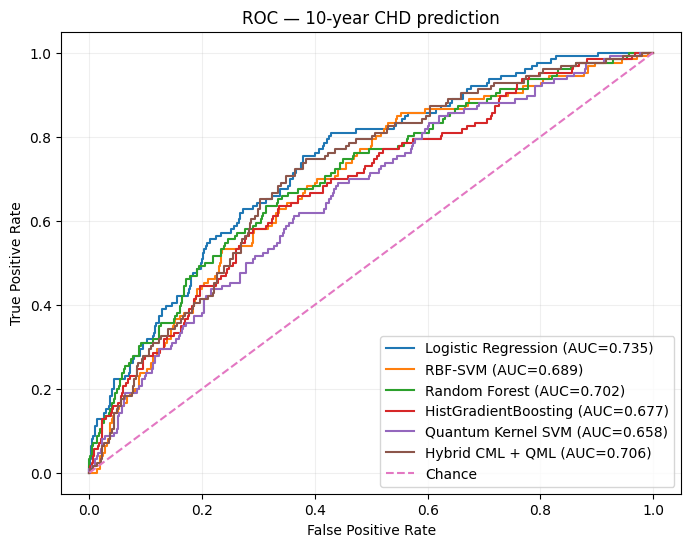

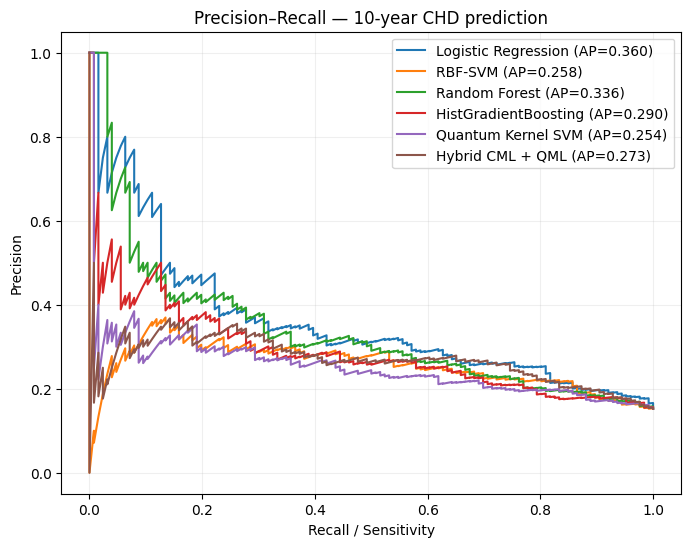

In [15]:
plt.figure(figsize=(8,6))
for name,prob in test_probs.items():
    fpr,tpr,_=roc_curve(y_test,prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y_test,prob):.3f})")
plt.plot([0,1],[0,1],"--",label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — 10-year CHD prediction"); plt.legend(); plt.grid(alpha=.2); plt.show()

plt.figure(figsize=(8,6))
for name,prob in test_probs.items():
    p,r,_=precision_recall_curve(y_test,prob)
    plt.plot(r,p,label=f"{name} (AP={average_precision_score(y_test,prob):.3f})")
plt.xlabel("Recall / Sensitivity"); plt.ylabel("Precision")
plt.title("Precision–Recall — 10-year CHD prediction"); plt.legend(); plt.grid(alpha=.2); plt.show()

## 10. Bootstrap confidence intervals
A single test score can be unstable. We bootstrap the held-out test set to estimate 95% confidence intervals for AUROC and AUPRC.

In [16]:
def bootstrap_ci(y_true, prob, metric, n_boot=1000, seed=SEED):
    rng=np.random.default_rng(seed); y=np.asarray(y_true); p=np.asarray(prob); vals=[]
    for _ in range(n_boot):
        idx=rng.integers(0,len(y),len(y))
        if len(np.unique(y[idx]))<2: continue
        vals.append(metric(y[idx],p[idx]))
    return np.percentile(vals,[2.5,50,97.5])

ci_rows=[]
for name,prob in test_probs.items():
    auc=bootstrap_ci(y_test,prob,roc_auc_score)
    ap=bootstrap_ci(y_test,prob,average_precision_score)
    ci_rows.append({"Model":name,
                    "AUROC median":auc[1],"AUROC 95% CI":f"{auc[0]:.3f}–{auc[2]:.3f}",
                    "AUPRC median":ap[1],"AUPRC 95% CI":f"{ap[0]:.3f}–{ap[2]:.3f}"})
display(pd.DataFrame(ci_rows).round(4))

,Model,AUROC median,AUROC 95% CI,AUPRC median,AUPRC 95% CI
0,Logistic Regression,0.7344,0.689–0.780,0.3648,0.282–0.452
1,RBF-SVM,0.6891,0.638–0.733,0.2602,0.208–0.328
2,Random Forest,0.7011,0.648–0.749,0.3381,0.264–0.419
3,HistGradientBoosting,0.6787,0.628–0.727,0.2933,0.229–0.370
4,Quantum Kernel SVM,0.6582,0.606–0.708,0.2573,0.199–0.323
5,Hybrid CML + QML,0.7054,0.660–0.753,0.2770,0.221–0.344


## 11. Explainability
For the faculty/SIH demo, show the classical branch's global feature importance. The final platform can add patient-level SHAP explanations; here we use permutation importance, which does not require an additional package.

,feature,importance
1,age,0.108495
10,sysBP,0.039906
0,sex_male,0.008795
14,glucose,0.008209
13,heartRate,0.003134
7,prevalentHyp,0.001861
11,diaBP,0.001433
6,prevalentStroke,-0.000371
5,BPMeds,-0.001427
3,currentSmoker,-0.002005


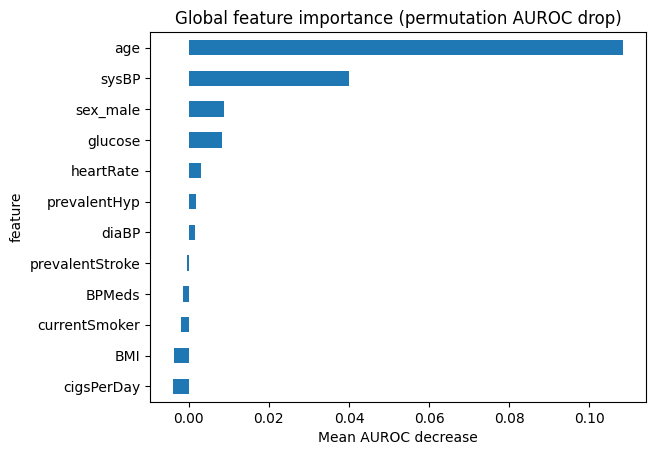

In [17]:
from sklearn.inspection import permutation_importance
best_explain = classical_models["RBF-SVM"]
perm = permutation_importance(best_explain,Xte,y_test,n_repeats=15,scoring="roc_auc",random_state=SEED,n_jobs=-1)
imp = pd.DataFrame({"feature":feature_names,"importance":perm.importances_mean}).sort_values("importance",ascending=False).head(12)
display(imp)
imp.sort_values("importance").plot.barh(x="feature",y="importance",legend=False,title="Global feature importance (permutation AUROC drop)")
plt.xlabel("Mean AUROC decrease"); plt.show()

## 12. Quantum Advantage Auditor
The notebook does **not** assume that quantum is superior. It measures whether the hybrid/quantum branches improve predictive performance and reports the result transparently.

In [18]:
res = pd.DataFrame(results).drop_duplicates("Model",keep="last").set_index("Model")
best_classical_name = res.loc[[i for i in res.index if i in classical_models]].AUROC.idxmax()
best_c_auc = res.loc[best_classical_name,"AUROC"]
q_auc = res.loc["Quantum Kernel SVM","AUROC"]
h_auc = res.loc["Hybrid CML + QML","AUROC"]

print("Best classical:",best_classical_name)
print(f"ΔAUROC Quantum - Classical = {q_auc-best_c_auc:+.4f}")
print(f"ΔAUROC Hybrid  - Classical = {h_auc-best_c_auc:+.4f}")

if h_auc > best_c_auc + 0.01:
    verdict="Hybrid improvement observed on this held-out split; repeated validation is still required."
elif h_auc >= best_c_auc - 0.01:
    verdict="Hybrid is approximately competitive on this held-out split; no quantum advantage established."
else:
    verdict="Classical baseline is stronger on this held-out split; no quantum advantage established."
print("AUDIT VERDICT:",verdict)

Best classical: Logistic Regression
ΔAUROC Quantum - Classical = -0.0764
ΔAUROC Hybrid  - Classical = -0.0283
AUDIT VERDICT: Classical baseline is stronger on this held-out split; no quantum advantage established.


## 13. Optional repeated classical validation
Quantum kernels are expensive, so this cell performs repeated CV only for classical baselines. For the final SIH submission, repeat the complete hybrid experiment across seeds/folds or use nested CV where computationally feasible.

In [19]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=SEED)
scoring={"AUROC":"roc_auc","AUPRC":"average_precision","Sensitivity":"recall","BalancedAcc":"balanced_accuracy"}
cv_rows=[]
for name,model in classical_models.items():
    out=cross_validate(model,Xtr,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    row={"Model":name}
    for metric in scoring:
        row[metric+" mean"]=out["test_"+metric].mean(); row[metric+" std"]=out["test_"+metric].std()
    cv_rows.append(row)
display(pd.DataFrame(cv_rows).round(4))

,Model,AUROC mean,AUROC std,AUPRC mean,AUPRC std,Sensitivity mean,Sensitivity std,BalancedAcc mean,BalancedAcc std
0,Logistic Regression,0.7186,0.0240,0.3375,0.0487,0.6600,0.0462,0.6661,0.0234
1,RBF-SVM,0.6849,0.0162,0.2681,0.0184,0.5604,0.0431,0.6343,0.0235
2,Random Forest,0.6908,0.0294,0.3009,0.0424,0.1494,0.0349,0.5524,0.0188
3,HistGradientBoosting,0.6615,0.0281,0.2894,0.0428,0.1062,0.0384,0.5410,0.0190


## 14. Export results for the SIH PPT

In [20]:
summary = pd.DataFrame(results).drop_duplicates("Model",keep="last").sort_values("AUROC",ascending=False)
summary.to_csv("/kaggle/working/sih26139_chd_model_results.csv",index=False)
feature_rank.to_csv("/kaggle/working/sih26139_feature_ranking.csv",index=False)
print("Saved result tables to /kaggle/working/")
display(summary.round(4))

Saved result tables to /kaggle/working/


,Model,Accuracy,Balanced Acc,Precision,Sensitivity,Specificity,F1,AUROC,AUPRC,Time_s
0,Logistic Regression,0.6989,0.6694,0.2811,0.6270,0.7118,0.3882,0.7345,0.3603,0.0210
5,Hybrid CML + QML,0.7207,0.6204,0.2667,0.4762,0.7646,0.3419,0.7062,0.2727,11.4532
2,Random Forest,0.8380,0.5594,0.4167,0.1587,0.9601,0.2299,0.7016,0.3362,1.3182
1,RBF-SVM,0.8476,0.5000,0.0000,0.0000,1.0000,0.0000,0.6886,0.2581,2.2919
3,HistGradientBoosting,0.8452,0.5441,0.4667,0.1111,0.9772,0.1795,0.6775,0.2903,0.3815
4,Quantum Kernel SVM,0.8452,0.5018,0.2500,0.0079,0.9957,0.0154,0.6581,0.2535,3.7862


# Interpretation for SIH26139

### What this notebook demonstrates
- **Early-risk formulation:** baseline clinical variables $\rightarrow$ future 10-year CHD event.
- **Classical preprocessing:** missing-value handling, standardization, feature selection.
- **CML benchmarking:** multiple strong classical baselines.
- **QML:** a qubit-compatible entangled quantum feature map and quantum-kernel SVM.
- **True predictive hybrid:** CML and QML probabilities are fused using leakage-safe OOF stacking.
- **Medical metrics:** sensitivity, specificity, AUROC and AUPRC in addition to accuracy.
- **Explainability:** global feature importance.
- **Scientific integrity:** a Quantum Advantage Auditor reports whether improvement is actually observed.

### What must NOT be claimed
A higher score on one split is **not proof of quantum advantage**. Simulator runtime is also not evidence of computational speedup. Clinical deployment would require external validation, calibration, fairness analysis, prospective testing, privacy/security controls, and regulatory/clinical review.

### Recommended next SIH milestones
1. Repeat hybrid evaluation across seeds and folds with confidence intervals.
2. Add a second longitudinal disease dataset.
3. Add shot-based/noisy quantum simulation and error mitigation.
4. Run a small representative experiment on real quantum hardware.
5. Add patient-level explainability and probability calibration.
6. Wrap the pipeline in the SIH web platform for ingestion, training, prediction and benchmarking.

In [21]:
# ============================================================
# Q-MedAI — FROZEN FRAMINGHAM ARTIFACT EXPORT
# COPY THIS ENTIRE FILE INTO ONE NEW KAGGLE CODE CELL
# AFTER the original Framingham notebook has trained:
#   preprocess, classical_models, selected, idx, S_train, qsvc,
#   c_final, q_final, Sh, meta, summary, clinical_threshold.
#
# This cell SERIALIZES already-fitted objects. It does not retrain.
# ============================================================
from __future__ import annotations

import hashlib
import json
import platform
import shutil
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd
import sklearn


FEATURE_MAP_VERSION = "framingham_v1_h_rz_cz_reupload"


def _require(ns: dict[str, Any], names: list[str]) -> None:
    missing = [name for name in names if name not in ns]
    if missing:
        raise KeyError("Missing required fitted notebook variable(s): " + ", ".join(missing))


def _jsonable_metrics(summary) -> list[dict[str, Any]]:
    if isinstance(summary, pd.DataFrame):
        return json.loads(summary.to_json(orient="records"))
    if isinstance(summary, list):
        return summary
    return []


def _package_versions() -> dict[str, str]:
    versions = {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
    }
    try:
        import pennylane as qml
        versions["pennylane"] = qml.__version__
    except Exception:
        versions["pennylane"] = "not-imported-during-export"
    return versions


def export_from_namespace(ns: dict[str, Any], output_dir: Path | str) -> Path:
    required = [
        "preprocess", "classical_models", "feature_names", "selected", "idx", "S_train", "qsvc",
        "q_idx", "c_final", "q_final", "Sh", "meta", "summary", "clinical_threshold", "SEED", "X_train", "X_test", "TARGET",
    ]
    _require(ns, required)
    output_dir = Path(output_dir)
    artifact_dir = output_dir / "artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)

    feature_order = [str(x) for x in list(ns["feature_names"])]
    selected = [str(x) for x in list(ns["selected"])]
    selected_indices = [int(x) for x in list(ns["idx"])]
    n_qubits = int(ns.get("N_QUBITS", len(selected)))
    if len(selected) != n_qubits or len(selected_indices) != n_qubits:
        raise ValueError("Quantum selected feature/index count must equal N_QUBITS")

    primary_name = "Logistic Regression"
    classical_models = ns["classical_models"]
    if primary_name not in classical_models:
        raise KeyError("classical_models must contain fitted Logistic Regression")

    creation = datetime.now(timezone.utc).isoformat()
    identity_text = f"Q-MedAI|Framingham|TenYearCHD|seed={ns['SEED']}|{creation}"
    version_id = "qmedai-framingham-" + hashlib.sha256(identity_text.encode()).hexdigest()[:12]

    classical_bundle = {
        "model_version_id": version_id,
        "feature_order": feature_order,
        "model_name": primary_name,
        "preprocess": ns["preprocess"],
        "model": classical_models[primary_name],
    }
    quantum_bundle = {
        "model_version_id": version_id,
        "feature_order": feature_order,
        "preprocess": ns["preprocess"],
        "selected_features": selected,
        "selected_indices": selected_indices,
        "n_qubits": n_qubits,
        "feature_map_version": FEATURE_MAP_VERSION,
        "train_states": np.asarray(ns["S_train"], dtype=complex),
        "qsvc": ns["qsvc"],
    }
    hybrid_bundle = {
        "model_version_id": version_id,
        "feature_order": feature_order,
        "preprocess": ns["preprocess"],
        "classical_base_model": ns["c_final"],
        "selected_features": selected,
        "selected_indices": selected_indices,
        "n_qubits": n_qubits,
        "feature_map_version": FEATURE_MAP_VERSION,
        "train_states": np.asarray(ns["Sh"], dtype=complex),
        "qsvc": ns["q_final"],
        "meta_model": ns["meta"],
    }

    joblib.dump(classical_bundle, artifact_dir / "classical_pipeline.joblib")
    joblib.dump(quantum_bundle, artifact_dir / "quantum_bundle.joblib")
    joblib.dump(hybrid_bundle, artifact_dir / "hybrid_bundle.joblib")

    metrics = _jsonable_metrics(ns["summary"])
    manifest = {
        "model_version_id": version_id,
        "project": "Q-MedAI",
        "dataset": "Framingham Heart Study-compatible cohort loaded by the notebook",
        "task": "Prospective 10-year coronary heart disease risk prediction from baseline clinical measurements",
        "target": str(ns["TARGET"]),
        "split": {"seed": int(ns["SEED"]), "test_size": float(len(ns["X_test"]) / (len(ns["X_train"]) + len(ns["X_test"])))},
        "feature_order": feature_order,
        "quantum": {
            "selected_features": selected,
            "selected_indices": selected_indices,
            "n_qubits": n_qubits,
            "feature_map_version": FEATURE_MAP_VERSION,
            "training_reference_rows": int(np.asarray(ns["S_train"]).shape[0]),
        },
        "versions": _package_versions(),
        "evaluation_metrics": metrics,
        "risk_policy": {
            "bands": {"low_upper": 0.10, "elevated_upper": 0.20},
            "band_note": "Prototype display bands; not validated clinical Framingham cutoffs.",
            "screening_threshold": None,
            "screening_threshold_note": "No locked classical screening threshold is exported from V1. The primary classical probability is shown continuously.",
            "research_thresholds": {
                "hybrid_v1": {
                    "threshold": float(ns["clinical_threshold"]),
                    "note": "Training-derived threshold for the V1 hybrid output only; not applied to the primary classical probability and not a diagnostic cutoff."
                }
            },
        },
        "backend": "PennyLane default.qubit (classical quantum-circuit simulator)",
        "artifact_created_at_utc": creation,
        "artifacts": {
            "classical": "classical_pipeline.joblib",
            "quantum": "quantum_bundle.joblib",
            "hybrid": "hybrid_bundle.joblib",
        },
        "provenance_notes": [
            "Artifacts are serialized from already-fitted notebook objects; the exporter does not retrain models.",
            "Primary patient-facing prediction is the frozen Logistic Regression probability.",
            "Quantum and hybrid outputs are research comparisons and are not promoted as validated clinical estimates.",
        ],
    }
    (artifact_dir / "model_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    req_lines = [
        f"numpy=={manifest['versions']['numpy']}",
        f"pandas=={manifest['versions']['pandas']}",
        f"scikit-learn=={manifest['versions']['scikit-learn']}",
        "joblib>=1.3,<2",
        "streamlit>=1.40,<2",
    ]
    if manifest['versions'].get('pennylane') not in (None, 'not-imported-during-export'):
        req_lines.append(f"pennylane=={manifest['versions']['pennylane']}")
    (artifact_dir / "artifact_requirements.txt").write_text("\n".join(req_lines) + "\n", encoding="utf-8")

    frozen_metrics = {
        "notebook_summary": metrics,
        "exported_model_version_id": version_id,
    }
    (artifact_dir / "frozen_notebook_metrics.json").write_text(json.dumps(frozen_metrics, indent=2), encoding="utf-8")

    zip_base = output_dir / "qmedai_framingham_artifacts"
    archive_path = shutil.make_archive(str(zip_base), "zip", root_dir=artifact_dir)
    assert Path(archive_path).exists()
    return artifact_dir

EXPORT_ROOT = Path("/kaggle/working/qmedai_framingham_export")
ARTIFACT_DIR = export_from_namespace(globals(), EXPORT_ROOT)

print("=" * 88)
print("Q-MedAI FROZEN ARTIFACT EXPORT COMPLETE")
print("=" * 88)
print("Artifact directory:", ARTIFACT_DIR)
print("Download this ZIP:", EXPORT_ROOT / "qmedai_framingham_artifacts.zip")
print()
print("Files:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", path.name)
print()
print("No models were retrained by this export cell.")


Q-MedAI FROZEN ARTIFACT EXPORT COMPLETE
Artifact directory: /kaggle/working/qmedai_framingham_export/artifacts
Download this ZIP: /kaggle/working/qmedai_framingham_export/qmedai_framingham_artifacts.zip

Files:
 - artifact_requirements.txt
 - classical_pipeline.joblib
 - frozen_notebook_metrics.json
 - hybrid_bundle.joblib
 - model_manifest.json
 - quantum_bundle.joblib

No models were retrained by this export cell.
